# Single Combination Contribution Visualization

## Drug

In [1]:
import pandas as pd
import os
import sys
import shap
scripts_path = os.path.abspath('../scripts')
if scripts_path not in sys.path:
    sys.path.append(scripts_path)

from explain_tools import *

In [2]:
#Drug1_name = 'tamoxifen'
#Drug2_name = 'docetaxel'
#cell_line_name = 'NCIH838'

Drug1_name = 'Linsitinib'
Drug2_name = 'Sorafenib'
cell_line_name = 'MELHO'

In [3]:

name_cids = pd.read_pickle("../data/SHAP/DrugComb_all_witch_CID_data_name2_CID_dict.pkl")

drug_cid_1 = str(name_cids[Drug1_name])
drug_cid_2 = str(name_cids[Drug2_name])

drug_shap_dir = '../data/SHAP'

drug_shap_1 = pd.read_csv(drug_shap_dir + '/' + drug_cid_1 + '_shap.csv', index_col=0)
drug_shap_2 = pd.read_csv(drug_shap_dir + '/' + drug_cid_2 + '_shap.csv', index_col=0)
drug_shap_1.fillna("", inplace=True)
drug_shap_2.fillna("", inplace=True)

In [4]:
mid_shap_dir = f'../data/SHAP/mid_shap_test_{Drug1_name}_{Drug2_name}_{cell_line_name}.csv'
mid_shap = pd.read_csv(mid_shap_dir)

In [5]:


drug_f1_comb_shap = get_combine_shap(drug_shap_1,mid_shap, 'drug_f1')
drug_f2_comb_shap = get_combine_shap(drug_shap_2,mid_shap, 'drug_f2')

In [6]:
explanation1 = shap.Explanation(
    values= drug_f1_comb_shap,
    base_values= 0.0,
    data=drug_shap_1['smiles'].to_list(),
)

explanation2 = shap.Explanation(
    values= drug_f2_comb_shap,
    base_values= 0.0,
    data=drug_shap_2['smiles'].to_list(),
)

In [7]:
shap.plots.text(explanation1, display=True)

Reconstructed SMILES string: CC1(O)CC(c2nc(-c3ccc4ccc(-c5ccccc5)nc4c3)c3c(N)nccn23)C1
Successfully mapped SHAP values to 32 out of 32 atoms.


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Gen

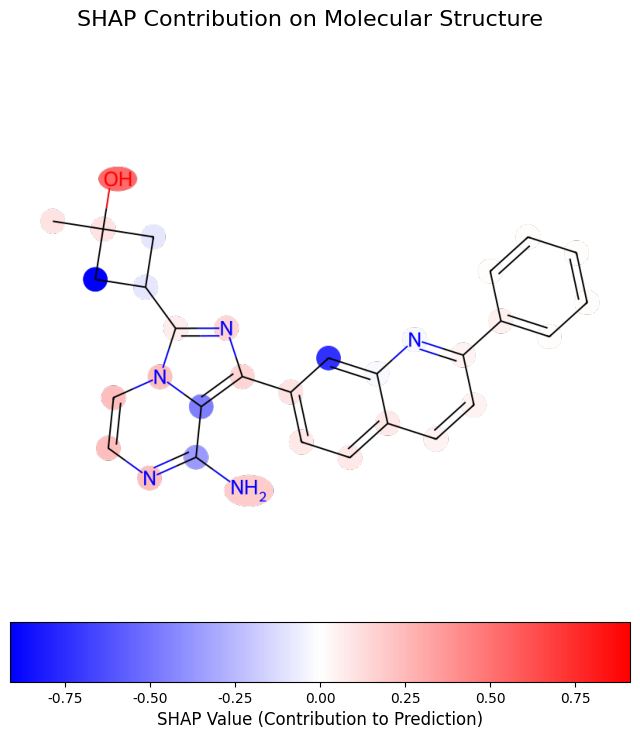

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Gen

In [8]:
save_path = f'../Figures/{Drug1_name}.pdf'

mol_picture(drug_f1_comb_shap*100,drug_shap_1['smiles'].to_list(),save_path,AtomIndices=False)

In [9]:
shap.plots.text(explanation2, display=True)

Reconstructed SMILES string: CNC(=O)c1cc(Oc2ccc(NC(=O)Nc3ccc(Cl)c(C(F)(F)F)c3)cc2)ccn1
Successfully mapped SHAP values to 32 out of 32 atoms.


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Gen

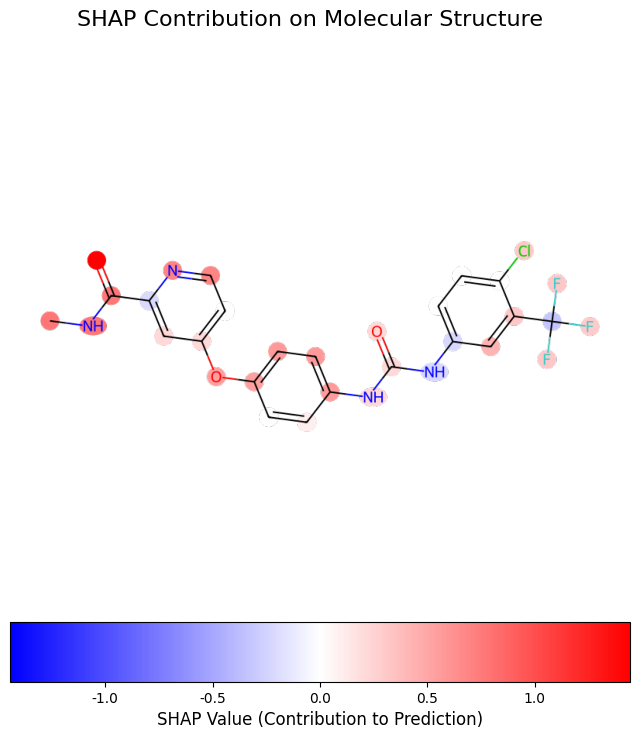

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Gen

In [12]:
save_path = f'../Figures/{Drug2_name}.pdf'

mol_picture2(drug_f2_comb_shap*100,drug_shap_2['smiles'].to_list(),save_path,AtomIndices=False)

## Cell line features

In [49]:
import shutil

In [50]:
gene_dict_dir = '../data/SHAP/gene_set_dict.json'


import json

# 读取 JSON 文件并转换为字典
with open(gene_dict_dir, 'r', encoding='utf-8') as file:
    gene_dict = json.load(file)
# 现在 data 是一个字典对象
print(type(gene_dict))  # <class 'dict'>

<class 'dict'>


In [51]:
CancerDiscovery_ls = list(gene_dict['Cancer_Discovery'])
Nature_ls = list(gene_dict['Nature'])

In [52]:
gene_dict.keys()

dict_keys(['Cancer_Discovery', 'Nature', 'TTD', 'DGIdb'])

In [53]:
model_dir = "../data/DrugComb/Process/Model.csv"
cell_model = pd.read_csv(model_dir,index_col=0)
sel_cell_line = cell_line_name

In [54]:
# GeneEffect
cell_id = cell_model[cell_model['StrippedCellLineName']==sel_cell_line].index.tolist()[0]

In [55]:
cell_id

'ACH-000450'

In [56]:
#geneDependency
geneDependency_shap_dir = '/mnt/hpc/home/shilei/RongfangNie/project/Nierongfang/DurgCombinationPredict/output/414/GeneDependency'
geneDependency_shap = pd.read_csv(f'{geneDependency_shap_dir}/{cell_id}_shap_values.csv',index_col=0)
comb_geneDependency =  get_combine_shap(geneDependency_shap,mid_shap, 'geneDependency_f',feature_num=256)


geneDependency_df = pd.DataFrame({'Feature':geneDependency_shap.index.tolist(),'Shap':comb_geneDependency})
geneDependency_df['Shap_abs'] = geneDependency_df['Shap'].abs()
geneDependency_df['Feature_new'] = [i.split(' ')[0] for i in geneDependency_df['Feature'].tolist()]

In [57]:
# GeneEffect


geneEffect_shap_dir = '../data/SHAP/GeneEffect'
geneEffect_shap = pd.read_csv(f'{geneEffect_shap_dir}/{cell_id}_shap_values.csv',index_col=0)
comb_geneEffect =  get_combine_shap(geneEffect_shap,mid_shap, 'geneEffect_f',feature_num=256)

geneEffect_df = pd.DataFrame({'Feature':geneEffect_shap.index.tolist(),'Shap':comb_geneEffect})
geneEffect_df['Shap_abs'] = geneEffect_df['Shap'].abs()
geneEffect_df['Feature_new'] = [i.split(' ')[0] for i in geneEffect_df['Feature'].tolist()]


In [58]:
# Gene


gene_shap_dir = '../data/SHAP/Cell_out'
gene_shap = pd.read_csv(f'{gene_shap_dir}/{cell_id}_shap_values.csv',index_col=0)
comb_gene =  get_combine_shap(gene_shap, mid_shap,'gene_f',feature_num=256)

gene_df = pd.DataFrame({'Feature':gene_shap.index.tolist(),'Shap':comb_gene})
gene_df['Shap_abs'] = gene_df['Shap'].abs()
gene_df['Feature_new'] = [i.split(' ')[0] for i in gene_df['Feature'].tolist()]

In [59]:
# methylation


methylation_shap_dir = '../data/SHAP/Methylation'
methylation_shap = pd.read_csv(f'{methylation_shap_dir}/{cell_id}_shap_values.csv',index_col=0)
comb_methylation =  get_combine_shap(methylation_shap, mid_shap,'methylation_f',feature_num=256)

methylation_df = pd.DataFrame({'Feature':methylation_shap.index.tolist(),'Shap':comb_methylation})
methylation_df['Shap_abs'] = methylation_df['Shap'].abs()
methylation_df['Feature_new'] = [i.split('_')[0] for i in methylation_df['Feature'].tolist()]

In [60]:
# CNV

CNV_shap_dir = '../data/SHAP/CNV'
CNV_shap = pd.read_csv(f'{CNV_shap_dir}/{cell_id}_shap_values.csv',index_col=0)
comb_CNV =  get_combine_shap(CNV_shap, mid_shap,'CNV_f',feature_num=256)

CNV_df = pd.DataFrame({'Feature':CNV_shap.index.tolist(),'Shap':comb_CNV})
CNV_df['Shap_abs'] = CNV_df['Shap'].abs()
CNV_df['Feature_new'] = [i.split(' ')[0] for i in CNV_df['Feature'].tolist()]


In [61]:
# mutation

import pandas as pd
import numpy as np

mutation_df = pd.read_pickle("../data/DrugComb/Process/Depmap_mutation_top_var_256.pkl")
tem_mid_mutation = mid_shap[mid_shap['feature_name'].str.contains('mutation')]
#tem_mid.reset_index(drop=True,inplace=True)
tem_mid_mutation.index = mutation_df.columns
tem_mid_mutation['Shap_abs'] = tem_mid_mutation['shap'].abs()
tem_mid_mutation['Feature_new'] = [i.split(' ')[0] for i in tem_mid_mutation.index.tolist()]

/tmp/ipykernel_8832/412431298.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tem_mid_mutation['Shap_abs'] = tem_mid_mutation['shap'].abs()
/tmp/ipykernel_8832/412431298.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tem_mid_mutation['Feature_new'] = [i.split(' ')[0] for i in tem_mid_mutation.index.tolist()]


In [62]:
# protein
import pandas as pd
import numpy as np

Protein_df = pd.read_table("../data/DrugComb/Process/TCPA_CCLE_RPPA500.tsv",sep='\t',index_col=0,header=0)
tem_mid_protein = mid_shap[mid_shap['feature_name'].str.contains('protein')]
tem_mid_protein.index = Protein_df.columns
tem_mid_protein['Shap_abs'] = tem_mid_protein['shap'].abs()
tem_mid_protein['Feature_new'] = tem_mid_protein.index.tolist()

/tmp/ipykernel_8832/2597752089.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tem_mid_protein['Shap_abs'] = tem_mid_protein['shap'].abs()
/tmp/ipykernel_8832/2597752089.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tem_mid_protein['Feature_new'] = tem_mid_protein.index.tolist()


In [63]:
# 组合所有含有基因的数据框
tem_mid_mutation['Shap'] = tem_mid_mutation['shap']
tem_mid_protein['Shap'] = tem_mid_protein['shap']
#书签
geneDependency_df['Feature_class'] = 'geneDependency'
geneEffect_df['Feature_class'] = 'geneEffect'
gene_df['Feature_class'] = 'gene'
methylation_df['Feature_class'] = 'methylation'
CNV_df['Feature_class'] = 'CNV'
tem_mid_mutation['Feature_class'] = 'mutation'
tem_mid_protein['Feature_class'] = 'protein'

/tmp/ipykernel_8832/262727017.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tem_mid_mutation['Shap'] = tem_mid_mutation['shap']
/tmp/ipykernel_8832/262727017.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tem_mid_protein['Shap'] = tem_mid_protein['shap']
/tmp/ipykernel_8832/262727017.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

In [64]:
comb_all_df = pd.concat([geneDependency_df[['Shap_abs','Feature_new']],
                        geneEffect_df[['Shap_abs','Feature_new']],
                        gene_df[['Shap_abs','Feature_new']],
                        methylation_df[['Shap_abs','Feature_new']],
                        CNV_df[['Shap_abs','Feature_new']],
                        tem_mid_mutation[['Shap_abs','Feature_new']],
                        tem_mid_protein[['Shap_abs','Feature_new']],
                        ])

In [65]:
map_df = pd.read_csv('../data/SHAP/map_df.csv')

In [66]:
comb_all_df.sort_values(by=['Shap_abs'], ascending=False,inplace=True)
comb_all_df.reset_index(drop=True,inplace=True)
# 在原数据框上直接修改，根据 Feature_new 列去重
comb_all_df.drop_duplicates(subset=['Feature_new'], keep='first', inplace=True)

In [67]:
first_gene_ls = list(gene_dict['Cancer_Discovery']) + list(gene_dict['Nature'])

first_gene_ls_TTD = list(gene_dict['TTD'])

first_gene_ls_DGIdb = list(gene_dict['DGIdb'])

In [68]:
new_Feature_new = []
new_abs_shap = []

for i in range(0,len(comb_all_df)):
    pri_g = comb_all_df.iloc[i,:]['Feature_new']
    pri_shap = comb_all_df.iloc[i,:]['Shap_abs']
    tem_map =  map_df[map_df['pri_gene'] == pri_g]['symbol'].tolist()
    if len(tem_map) == 0:
        continue
    elif len(tem_map) > 0:
        for l in tem_map:
            #print(l)
            new_Feature_new.append(l)
            new_abs_shap.append(pri_shap)
    else:
        new_Feature_new.append(l)
        new_abs_shap.append(tem_map[0])
        
nrm_comb_all_df = pd.DataFrame({'Feature_new':new_Feature_new,'Shap_abs':new_abs_shap})

nrm_comb_all_df.drop_duplicates(subset=['Feature_new'], keep='first', inplace=True)

In [69]:
top_num_ls = []
odds_ratio_ls = []
p_value_ls = []

cut_num = 100

for i in range(cut_num,len(nrm_comb_all_df)-cut_num,cut_num):
    #print(i)
    odds_ratio,p_value =   get_fisher_exact_value(nrm_comb_all_df, first_gene_ls,colname_feature='Feature_new',top_num=i,colname_Rank='Shap_abs')
    top_num_ls.append(i)
    odds_ratio_ls.append(odds_ratio)
    p_value_ls.append(p_value)

fisher_exact_df = pd.DataFrame({'top_num':top_num_ls,'odds_ratio':odds_ratio_ls,'p_value':p_value_ls})

In [70]:
top_num_ls = []
odds_ratio_ls = []
p_value_ls = []

cut_num = 100

for i in range(cut_num,len(nrm_comb_all_df)-cut_num,cut_num):
    #print(i)
    odds_ratio,p_value =   get_fisher_exact_value(nrm_comb_all_df, first_gene_ls_TTD,colname_feature='Feature_new',top_num=i,colname_Rank='Shap_abs')
    top_num_ls.append(i)
    odds_ratio_ls.append(odds_ratio)
    p_value_ls.append(p_value)

fisher_exact_df_TTD = pd.DataFrame({'top_num':top_num_ls,'odds_ratio':odds_ratio_ls,'p_value':p_value_ls})

In [71]:
top_num_ls = []
odds_ratio_ls = []
p_value_ls = []

cut_num = 100

for i in range(cut_num,len(nrm_comb_all_df)-cut_num,cut_num):
    #print(i)
    odds_ratio,p_value =   get_fisher_exact_value(nrm_comb_all_df, first_gene_ls_DGIdb,colname_feature='Feature_new',top_num=i,colname_Rank='Shap_abs')
    top_num_ls.append(i)
    odds_ratio_ls.append(odds_ratio)
    p_value_ls.append(p_value)

fisher_exact_df_DGIdb = pd.DataFrame({'top_num':top_num_ls,'odds_ratio':odds_ratio_ls,'p_value':p_value_ls})

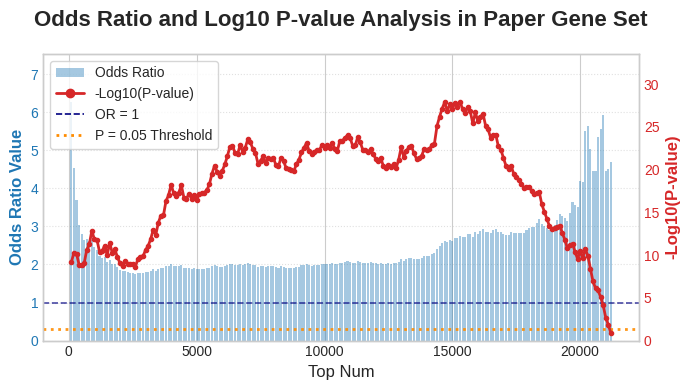

In [72]:
save_path = f'../Figures/{Drug1_name}_{Drug2_name}_{cell_line_name}_Paper_gene_enrichment.pdf'

plot_odds_ratio_and_log_pvalue_combined(fisher_exact_df, title="Odds Ratio and Log10 P-value Analysis in Paper Gene Set",save_path = save_path)


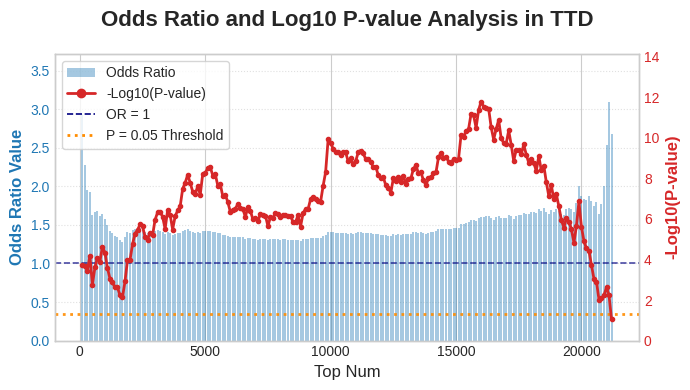

In [73]:
save_path = f'../Figures/{Drug1_name}_{Drug2_name}_{cell_line_name}_TTD_gene_enrichment.pdf'

plot_odds_ratio_and_log_pvalue_combined(fisher_exact_df_TTD, title="Odds Ratio and Log10 P-value Analysis in TTD",save_path=save_path)


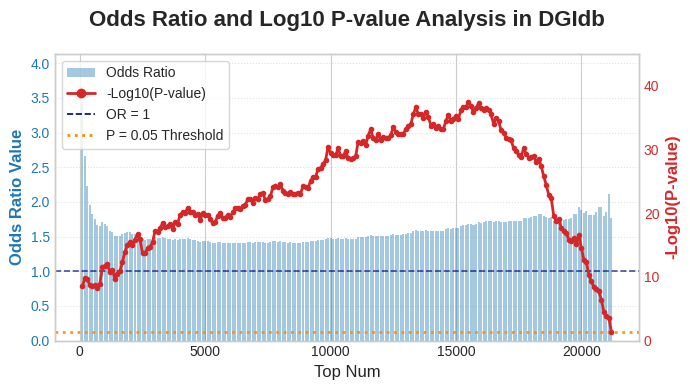

In [74]:
save_path = f'../Figures/{Drug1_name}_{Drug2_name}_{cell_line_name}_DGIdb_gene_enrichment.pdf'

plot_odds_ratio_and_log_pvalue_combined(fisher_exact_df_DGIdb, title="Odds Ratio and Log10 P-value Analysis in DGIdb",save_path=save_path)
